In [ ]:
# ============================================================
# CELL 1 — GPU / ENVIRONMENT CHECK
# ============================================================

import os
import sys
import platform

print("=" * 60)
print("TraffIQ LPSR Training")
print("=" * 60)

print("Python:", sys.version)
print("Platform:", platform.platform())

import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    props = torch.cuda.get_device_properties(0)
    print(f"VRAM: {props.total_memory / (1024**3):.2f} GB")
else:
    print("WARNING: GPU is NOT available.")

print("=" * 60)

TraffIQ LPSR Training
Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
Platform: Linux-6.6.122+-x86_64-with-glibc2.39
PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
VRAM: 14.56 GB


In [ ]:
# ============================================================
# COMMON IMPORTS — RUN ONCE
# ============================================================

import os
import sys
import math
import json
import random
import shutil
import zipfile
import time

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from PIL import (
    Image,
    ImageFilter,
    ImageEnhance,
    ImageOps
)

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import (
    Dataset,
    DataLoader
)

print("All common imports loaded.")

All common imports loaded.


In [ ]:
# ============================================================
# CELL 2 — GOOGLE DRIVE
# ============================================================

from google.colab import drive

drive.mount('/content/drive')

print("Google Drive mounted successfully.")

Mounted at /content/drive
Google Drive mounted successfully.


In [ ]:
# ============================================================
# CELL 3 — TRAFFIQ PROJECT PATHS
# ============================================================

from pathlib import Path

PROJECT_ROOT = Path("/content/drive/MyDrive/car_detection")

DATASET_DIR = PROJECT_ROOT / "Dataset"
MODEL_DIR = PROJECT_ROOT / "model"
VIDEOS_DIR = PROJECT_ROOT / "Training_Img_Vids"

LPSR_NOTEBOOK = PROJECT_ROOT / "TraffIQ_LPSR_Training.ipynb"

ARCHIVE_PATH = PROJECT_ROOT / "archive (1).zip"
CHAR_PIPELINE_ZIP = PROJECT_ROOT / "anpr_character_pipeline.zip"

# LPSR working directory
LPSR_DIR = PROJECT_ROOT / "LPSR"

# Outputs
LPSR_DATA_DIR = LPSR_DIR / "data"
LPSR_CROPS_DIR = LPSR_DATA_DIR / "plate_crops"
LPSR_CHECKPOINT_DIR = LPSR_DIR / "checkpoints"
LPSR_RESULTS_DIR = LPSR_DIR / "results"

# Create folders
for p in [
    LPSR_DIR,
    LPSR_DATA_DIR,
    LPSR_CROPS_DIR,
    LPSR_CHECKPOINT_DIR,
    LPSR_RESULTS_DIR
]:
    p.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT :", PROJECT_ROOT)
print("DATASET_DIR  :", DATASET_DIR)
print("MODEL_DIR    :", MODEL_DIR)
print("VIDEOS_DIR   :", VIDEOS_DIR)
print("ARCHIVE      :", ARCHIVE_PATH)
print("LPSR_DIR     :", LPSR_DIR)

PROJECT_ROOT : /content/drive/MyDrive/car_detection
DATASET_DIR  : /content/drive/MyDrive/car_detection/Dataset
MODEL_DIR    : /content/drive/MyDrive/car_detection/model
VIDEOS_DIR   : /content/drive/MyDrive/car_detection/Training_Img_Vids
ARCHIVE      : /content/drive/MyDrive/car_detection/archive (1).zip
LPSR_DIR     : /content/drive/MyDrive/car_detection/LPSR


In [ ]:
# ============================================================
# CELL 4 — VERIFY DRIVE STRUCTURE
# ============================================================

print("=" * 60)
print("PROJECT ROOT EXISTS:", PROJECT_ROOT.exists())
print("=" * 60)

if not PROJECT_ROOT.exists():
    raise FileNotFoundError(
        f"Project folder not found:\n{PROJECT_ROOT}"
    )

for item in sorted(PROJECT_ROOT.iterdir()):
    if item.is_dir():
        print("[DIR ]", item.name)
    else:
        print("[FILE]", item.name)

print("=" * 60)

PROJECT ROOT EXISTS: True
[DIR ] .ipynb_checkpoints
[DIR ] Dataset
[DIR ] LPSR
[FILE] TraffIQ_LPSR_Training.ipynb
[DIR ] Training_Img_Vids
[FILE] anpr_character_pipeline.zip
[FILE] archive (1).zip
[DIR ] model


In [ ]:
# ============================================================
# CELL 5 — INSPECT DATASET FOLDER
# ============================================================

def show_tree(path, max_depth=2, indent=""):
    path = Path(path)

    if not path.exists():
        print("NOT FOUND:", path)
        return

    items = sorted(path.iterdir())

    for item in items:
        print(indent + ("[DIR ] " if item.is_dir() else "[FILE] ") + item.name)

        if item.is_dir() and max_depth > 0:
            show_tree(item, max_depth - 1, indent + "    ")

print("DATASET STRUCTURE")
print("=" * 60)

show_tree(DATASET_DIR, max_depth=3)

DATASET STRUCTURE
[FILE] Dataset1.zip
[FILE] Dataset2.zip
[FILE] Dataset3.zip


In [ ]:
# ============================================================
# CELL 6 — INSPECT ARCHIVE CONTENTS
# ============================================================

import zipfile

if not ARCHIVE_PATH.exists():
    raise FileNotFoundError(
        f"Could not find:\n{ARCHIVE_PATH}"
    )

with zipfile.ZipFile(ARCHIVE_PATH, "r") as z:
    files = z.namelist()

print("Archive:")
print(ARCHIVE_PATH)
print()
print("Total entries:", len(files))
print()

for f in files[:100]:
    print(f)

if len(files) > 100:
    print()
    print(f"... and {len(files)-100} more entries")

Archive:
/content/drive/MyDrive/car_detection/archive (1).zip

Total entries: 4104

images/00000000.jpg
images/00000001.jpg
images/00000002.jpg
images/00000003.jpg
images/00000004.jpg
images/00000005.jpg
images/00000006.jpg
images/00000008.jpg
images/00000009.jpg
images/00000010.jpg
images/00000011.jpg
images/00000012.jpg
images/00000014.jpg
images/00000015.jpg
images/00000017.jpg
images/00000018.jpg
images/00000019.jpg
images/00000020.jpg
images/00000023.jpg
images/00000024.jpg
images/00000025.jpg
images/00000026.jpg
images/00000027.jpg
images/00000028.jpg
images/00000029.jpg
images/00000030.jpg
images/00000032.jpg
images/00000033.jpg
images/00000035.jpg
images/00000037.jpg
images/00000038.jpg
images/00000041.jpg
images/00000042.jpg
images/00000043.jpg
images/00000044.jpg
images/00000045.jpg
images/00000046.jpg
images/00000049.jpg
images/00000053.jpg
images/00000054.jpg
images/00000056.jpg
images/00000061.jpg
images/00000062.jpg
images/00000064.jpg
images/00000066.jpg
images/00000067.

In [ ]:
# ============================================================
# CELL 7 — COUNT IMAGE / LABEL FILES IN ZIP
# ============================================================

image_exts = (
    ".jpg", ".jpeg", ".png",
    ".bmp", ".webp"
)

label_exts = (
    ".txt", ".xml", ".json"
)

image_files = [
    f for f in files
    if f.lower().endswith(image_exts)
]

label_files = [
    f for f in files
    if f.lower().endswith(label_exts)
]

print("Images:", len(image_files))
print("Labels/annotations:", len(label_files))

print("\nExample images:")
for f in image_files[:20]:
    print(" ", f)

print("\nExample annotations:")
for f in label_files[:20]:
    print(" ", f)

Images: 2083
Labels/annotations: 2021

Example images:
  images/00000000.jpg
  images/00000001.jpg
  images/00000002.jpg
  images/00000003.jpg
  images/00000004.jpg
  images/00000005.jpg
  images/00000006.jpg
  images/00000008.jpg
  images/00000009.jpg
  images/00000010.jpg
  images/00000011.jpg
  images/00000012.jpg
  images/00000014.jpg
  images/00000015.jpg
  images/00000017.jpg
  images/00000018.jpg
  images/00000019.jpg
  images/00000020.jpg
  images/00000023.jpg
  images/00000024.jpg

Example annotations:
  labels/00000000.txt
  labels/00000001.txt
  labels/00000002.txt
  labels/00000003.txt
  labels/00000004.txt
  labels/00000005.txt
  labels/00000006.txt
  labels/00000008.txt
  labels/00000009.txt
  labels/00000010.txt
  labels/00000011.txt
  labels/00000012.txt
  labels/00000014.txt
  labels/00000015.txt
  labels/00000017.txt
  labels/00000018.txt
  labels/00000019.txt
  labels/00000020.txt
  labels/00000023.txt
  labels/00000024.txt


In [ ]:
# ============================================================
# CELL 8 — EXTRACT DATASET
# ============================================================

import zipfile
import shutil

EXTRACT_DIR = LPSR_DATA_DIR / "downloaded_dataset"

if EXTRACT_DIR.exists():
    print("Extraction folder already exists:")
    print(EXTRACT_DIR)
else:
    EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(ARCHIVE_PATH, "r") as z:
        z.extractall(EXTRACT_DIR)

    print("Dataset extracted successfully.")

print("\nExtracted structure:")
show_tree(EXTRACT_DIR, max_depth=4)

Dataset extracted successfully.

Extracted structure:
[DIR ] images
    [FILE] 00000000.jpg
    [FILE] 00000001.jpg
    [FILE] 00000002.jpg
    [FILE] 00000003.jpg
    [FILE] 00000004.jpg
    [FILE] 00000005.jpg
    [FILE] 00000006.jpg
    [FILE] 00000008.jpg
    [FILE] 00000009.jpg
    [FILE] 00000010.jpg
    [FILE] 00000011.jpg
    [FILE] 00000012.jpg
    [FILE] 00000014.jpg
    [FILE] 00000015.jpg
    [FILE] 00000017.jpg
    [FILE] 00000018.jpg
    [FILE] 00000019.jpg
    [FILE] 00000020.jpg
    [FILE] 00000023.jpg
    [FILE] 00000024.jpg
    [FILE] 00000025.jpg
    [FILE] 00000026.jpg
    [FILE] 00000027.jpg
    [FILE] 00000028.jpg
    [FILE] 00000029.jpg
    [FILE] 00000030.jpg
    [FILE] 00000032.jpg
    [FILE] 00000033.jpg
    [FILE] 00000035.jpg
    [FILE] 00000037.jpg
    [FILE] 00000038.jpg
    [FILE] 00000041.jpg
    [FILE] 00000042.jpg
    [FILE] 00000043.jpg
    [FILE] 00000044.jpg
    [FILE] 00000045.jpg
    [FILE] 00000046.jpg
    [FILE] 00000049.jpg
    [FILE] 00000053.

In [ ]:
# ============================================================
# CELL 9 — FIND DATASET IMAGES
# ============================================================

IMAGE_EXTS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
}

dataset_images = [
    p for p in EXTRACT_DIR.rglob("*")
    if p.is_file() and p.suffix.lower() in IMAGE_EXTS
]

print("Total images found:", len(dataset_images))

print("\nFirst 30 images:")

for p in dataset_images[:30]:
    print(p)

Total images found: 2083

First 30 images:
/content/drive/MyDrive/car_detection/LPSR/data/downloaded_dataset/images/00000000.jpg
/content/drive/MyDrive/car_detection/LPSR/data/downloaded_dataset/images/00000001.jpg
/content/drive/MyDrive/car_detection/LPSR/data/downloaded_dataset/images/00000002.jpg
/content/drive/MyDrive/car_detection/LPSR/data/downloaded_dataset/images/00000003.jpg
/content/drive/MyDrive/car_detection/LPSR/data/downloaded_dataset/images/00000004.jpg
/content/drive/MyDrive/car_detection/LPSR/data/downloaded_dataset/images/00000005.jpg
/content/drive/MyDrive/car_detection/LPSR/data/downloaded_dataset/images/00000006.jpg
/content/drive/MyDrive/car_detection/LPSR/data/downloaded_dataset/images/00000008.jpg
/content/drive/MyDrive/car_detection/LPSR/data/downloaded_dataset/images/00000009.jpg
/content/drive/MyDrive/car_detection/LPSR/data/downloaded_dataset/images/00000010.jpg
/content/drive/MyDrive/car_detection/LPSR/data/downloaded_dataset/images/00000011.jpg
/content/dr

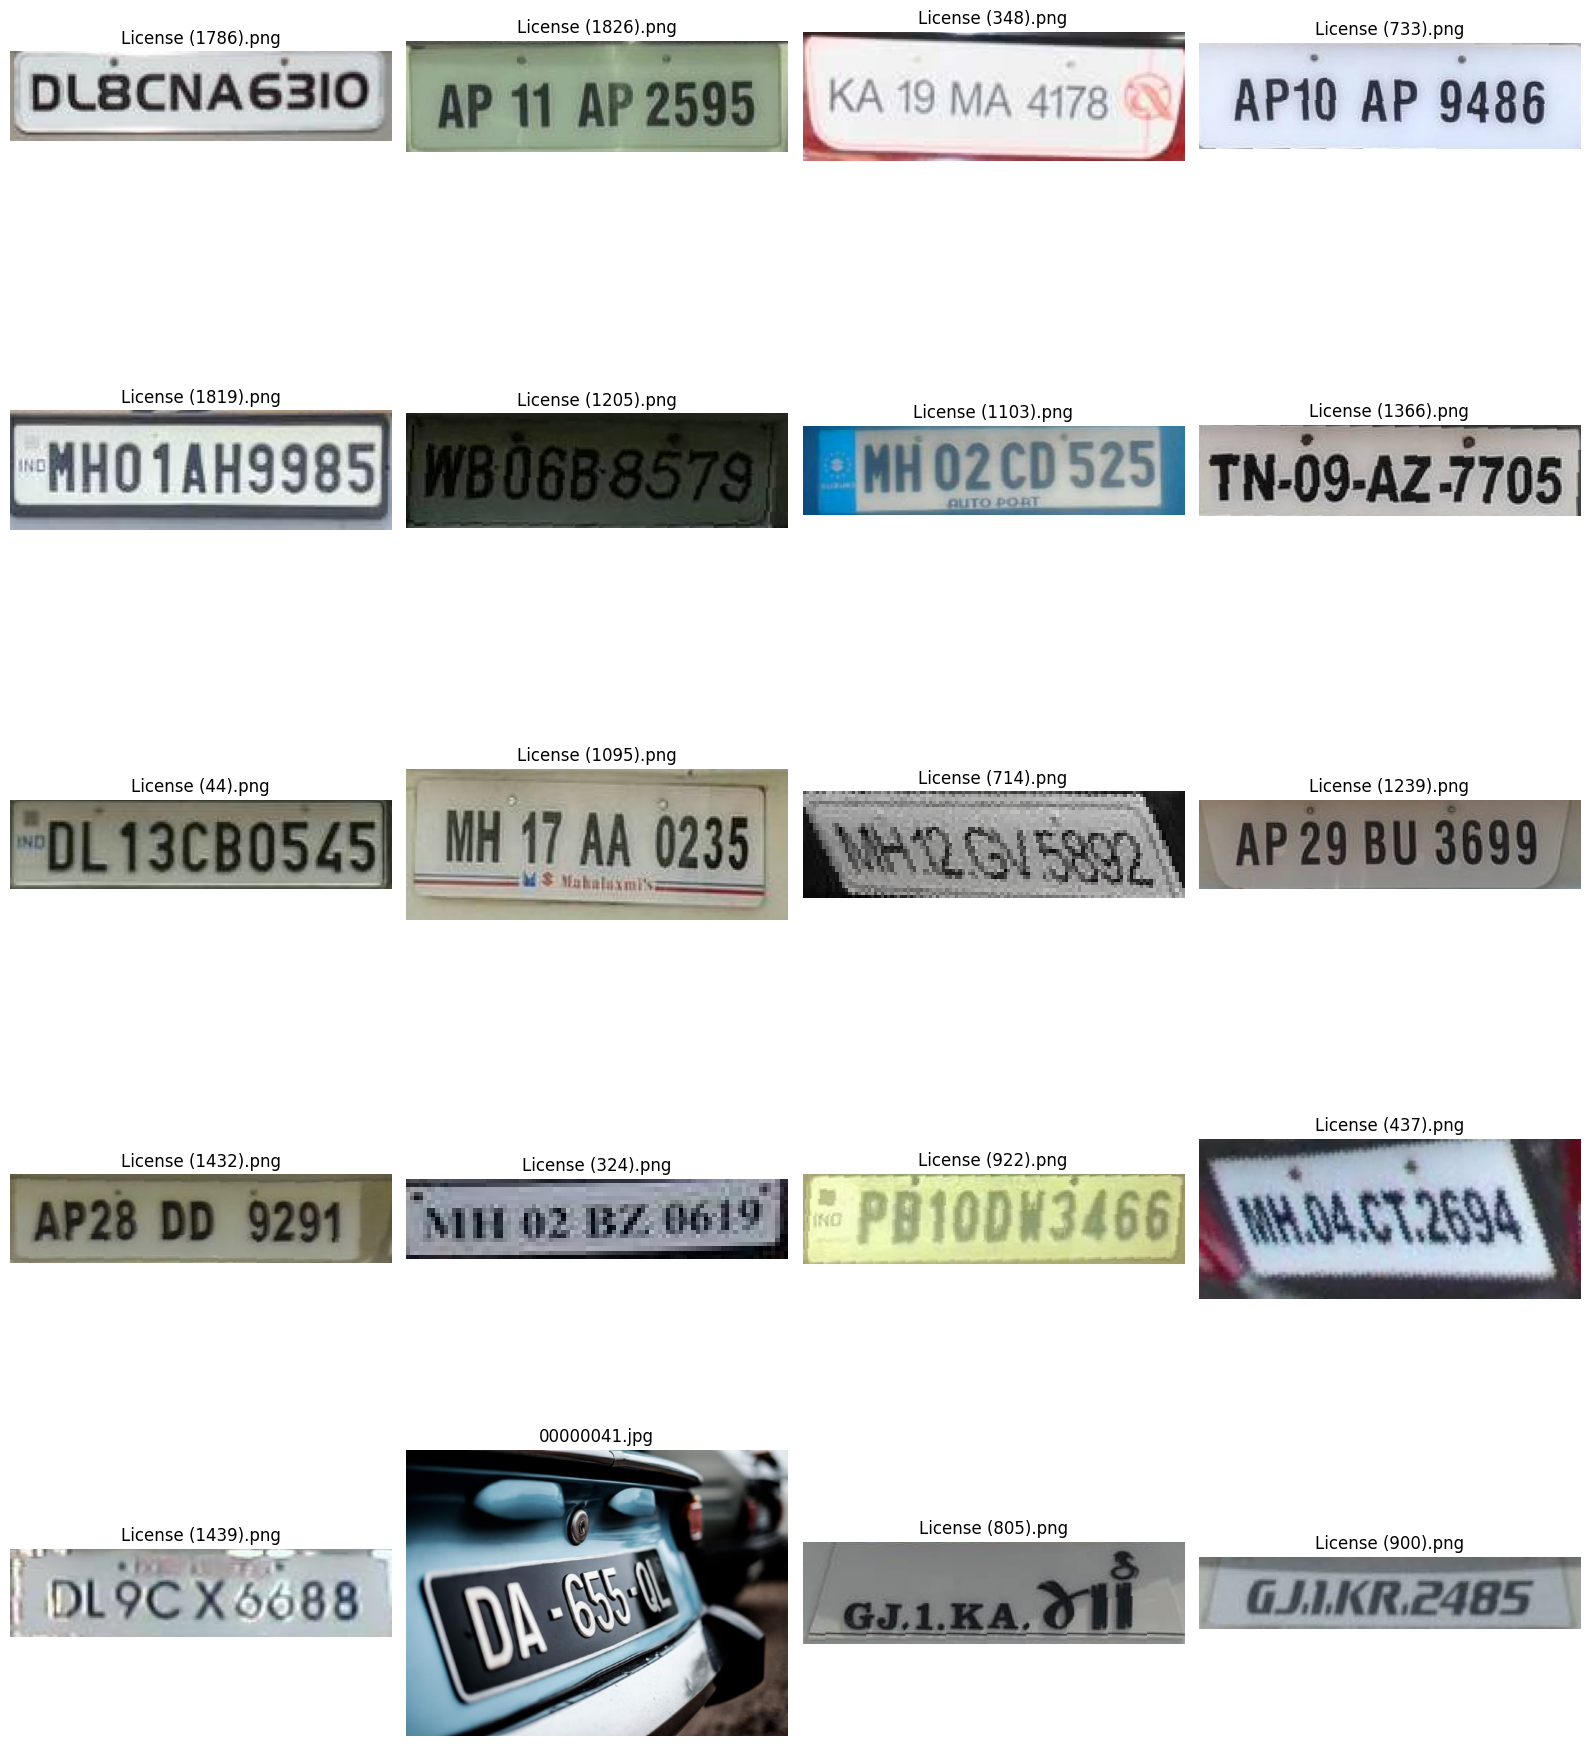

In [ ]:
# ============================================================
# CELL 10 — DATASET VISUAL INSPECTION
# ============================================================

from PIL import Image
import matplotlib.pyplot as plt
import random
import math

if len(dataset_images) == 0:
    raise RuntimeError("No images found in extracted dataset.")

sample_count = min(20, len(dataset_images))
samples = random.sample(dataset_images, sample_count)

cols = 4
rows = math.ceil(sample_count / cols)

plt.figure(figsize=(16, rows * 4))

for i, path in enumerate(samples):
    try:
        img = Image.open(path).convert("RGB")

        ax = plt.subplot(rows, cols, i + 1)
        ax.imshow(img)
        ax.set_title(path.name[:30])
        ax.axis("off")

    except Exception as e:
        print("Could not open:", path, e)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# CELL 11 — DATASET STATISTICS + SAFETY CHECK
# ============================================================

from pathlib import Path
from PIL import Image
import numpy as np

IMAGE_EXTS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
}

def list_images(root):
    root = Path(root)

    if not root.exists():
        return []

    return sorted([
        p for p in root.rglob("*")
        if p.is_file() and p.suffix.lower() in IMAGE_EXTS
    ])


# ------------------------------------------------------------
# 1. Make sure the project path is correct
# ------------------------------------------------------------

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/car_detection"
)

print("PROJECT ROOT:")
print(PROJECT_ROOT)

if not PROJECT_ROOT.exists():
    raise FileNotFoundError(
        f"Project folder not found:\n{PROJECT_ROOT}"
    )


# ------------------------------------------------------------
# 2. Find the LPSR dataset
# ------------------------------------------------------------

possible_dirs = [

    # Existing plate crop folder
    PROJECT_ROOT / "LPSR" / "data" / "plate_crops",

    # Extracted dataset
    PROJECT_ROOT / "LPSR" / "data" / "downloaded_dataset",

    # Dataset folder
    PROJECT_ROOT / "Dataset",

]


source_files = []

for folder in possible_dirs:

    if folder.exists():

        files_found = list_images(folder)

        print(
            f"\nChecking: {folder}"
        )

        print(
            f"Images found: {len(files_found)}"
        )

        if len(files_found) > len(source_files):

            source_files = files_found

            SOURCE_DIR = folder


# ------------------------------------------------------------
# 3. Safety check
# ------------------------------------------------------------

if len(source_files) == 0:

    raise RuntimeError(
        """
No license-plate images were found.

Expected one of:

/content/drive/MyDrive/car_detection/LPSR/data/plate_crops

or

/content/drive/MyDrive/car_detection/LPSR/data/downloaded_dataset

or

/content/drive/MyDrive/car_detection/Dataset

Check your dataset location.
"""
    )


print("\n" + "=" * 60)
print("LPSR DATASET FOUND")
print("=" * 60)

print("Source directory:")
print(SOURCE_DIR)

print()
print("Total images:")
print(len(source_files))

print()
print("First 10 images:")

for p in source_files[:10]:
    print(" ", p)


# ------------------------------------------------------------
# 4. Image statistics
# ------------------------------------------------------------

widths = []
heights = []

valid = 0
invalid = 0

for p in source_files:

    try:

        with Image.open(p) as im:

            w, h = im.size

            if w > 0 and h > 0:

                widths.append(w)
                heights.append(h)

                valid += 1

            else:

                invalid += 1

    except Exception:

        invalid += 1


print("\n" + "=" * 60)
print("IMAGE STATISTICS")
print("=" * 60)

print("Total files :", len(source_files))
print("Valid       :", valid)
print("Invalid     :", invalid)

if valid > 0:

    print("\nWidth")
    print(" Min :", min(widths))
    print(" Max :", max(widths))
    print(" Avg :", round(np.mean(widths), 2))

    print("\nHeight")
    print(" Min :", min(heights))
    print(" Max :", max(heights))
    print(" Avg :", round(np.mean(heights), 2))

print("=" * 60)

PROJECT ROOT:
/content/drive/MyDrive/car_detection

Checking: /content/drive/MyDrive/car_detection/LPSR/data/plate_crops
Images found: 0

Checking: /content/drive/MyDrive/car_detection/LPSR/data/downloaded_dataset
Images found: 2083

Checking: /content/drive/MyDrive/car_detection/Dataset
Images found: 0

LPSR DATASET FOUND
Source directory:
/content/drive/MyDrive/car_detection/LPSR/data/downloaded_dataset

Total images:
2083

First 10 images:
  /content/drive/MyDrive/car_detection/LPSR/data/downloaded_dataset/images/00000000.jpg
  /content/drive/MyDrive/car_detection/LPSR/data/downloaded_dataset/images/00000001.jpg
  /content/drive/MyDrive/car_detection/LPSR/data/downloaded_dataset/images/00000002.jpg
  /content/drive/MyDrive/car_detection/LPSR/data/downloaded_dataset/images/00000003.jpg
  /content/drive/MyDrive/car_detection/LPSR/data/downloaded_dataset/images/00000004.jpg
  /content/drive/MyDrive/car_detection/LPSR/data/downloaded_dataset/images/00000005.jpg
  /content/drive/MyDrive/

In [ ]:
# ============================================================
# CELL 12 — SET LPSR PLATE IMAGE SOURCE
# ============================================================

from pathlib import Path

PROJECT_ROOT = Path("/content/drive/MyDrive/car_detection")

DATASET_ROOT = (
    PROJECT_ROOT
    / "LPSR"
    / "data"
    / "downloaded_dataset"
)

PLATE_IMAGE_DIR = DATASET_ROOT / "images"
LABEL_DIR = DATASET_ROOT / "labels"

IMAGE_EXTS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
}

source_files = sorted([
    p for p in PLATE_IMAGE_DIR.rglob("*")
    if p.is_file()
    and p.suffix.lower() in IMAGE_EXTS
])

print("=" * 60)
print("LPSR DATASET")
print("=" * 60)

print("Image directory:")
print(PLATE_IMAGE_DIR)

print("Label directory:")
print(LABEL_DIR)

print()
print("Images:", len(source_files))

print()
print("First 10 images:")

for p in source_files[:10]:
    print(p)

print("=" * 60)

LPSR DATASET
Image directory:
/content/drive/MyDrive/car_detection/LPSR/data/downloaded_dataset/images
Label directory:
/content/drive/MyDrive/car_detection/LPSR/data/downloaded_dataset/labels

Images: 2083

First 10 images:
/content/drive/MyDrive/car_detection/LPSR/data/downloaded_dataset/images/00000000.jpg
/content/drive/MyDrive/car_detection/LPSR/data/downloaded_dataset/images/00000001.jpg
/content/drive/MyDrive/car_detection/LPSR/data/downloaded_dataset/images/00000002.jpg
/content/drive/MyDrive/car_detection/LPSR/data/downloaded_dataset/images/00000003.jpg
/content/drive/MyDrive/car_detection/LPSR/data/downloaded_dataset/images/00000004.jpg
/content/drive/MyDrive/car_detection/LPSR/data/downloaded_dataset/images/00000005.jpg
/content/drive/MyDrive/car_detection/LPSR/data/downloaded_dataset/images/00000006.jpg
/content/drive/MyDrive/car_detection/LPSR/data/downloaded_dataset/images/00000008.jpg
/content/drive/MyDrive/car_detection/LPSR/data/downloaded_dataset/images/00000009.jpg
/

In [ ]:
# ============================================================
# CELL 13 — CHECK IMAGE / LABEL MATCHING
# ============================================================

image_stems = {
    p.stem
    for p in source_files
}

label_files = sorted([
    p for p in LABEL_DIR.rglob("*.txt")
    if p.is_file()
])

label_stems = {
    p.stem
    for p in label_files
}

images_without_labels = image_stems - label_stems
labels_without_images = label_stems - image_stems

print("=" * 60)
print("IMAGE / LABEL CHECK")
print("=" * 60)

print("Images:", len(image_stems))
print("Labels:", len(label_stems))

print()
print("Images without labels:", len(images_without_labels))
print("Labels without images:", len(labels_without_images))

if images_without_labels:
    print("\nExample images without labels:")
    for x in sorted(images_without_labels)[:20]:
        print(x)

if labels_without_images:
    print("\nExample labels without images:")
    for x in sorted(labels_without_images)[:20]:
        print(x)

print("=" * 60)

IMAGE / LABEL CHECK
Images: 2083
Labels: 2021

Images without labels: 62
Labels without images: 0

Example images without labels:
License (943)
License (944)
License (945)
License (946)
License (947)
License (948)
License (949)
License (95)
License (950)
License (951)
License (952)
License (953)
License (954)
License (955)
License (956)
License (957)
License (958)
License (959)
License (96)
License (960)


In [ ]:
# ============================================================
# CELL 14 — PLATE QUALITY / ASPECT RATIO ANALYSIS
# ============================================================

from PIL import Image
import numpy as np

records = []

for p in source_files:

    try:

        with Image.open(p) as im:

            w, h = im.size

            if h == 0:
                continue

            aspect = w / h

            records.append({
                "path": p,
                "width": w,
                "height": h,
                "aspect": aspect
            })

    except Exception:
        pass


aspects = np.array([
    r["aspect"]
    for r in records
])

print("=" * 60)
print("ASPECT RATIO ANALYSIS")
print("=" * 60)

print("Valid images:", len(records))

print()
print("Aspect ratio:")
print("Minimum :", round(aspects.min(), 2))
print("Maximum :", round(aspects.max(), 2))
print("Average :", round(aspects.mean(), 2))
print("Median  :", round(np.median(aspects), 2))

print("=" * 60)

print("\nPotentially unusual images:")

unusual = [
    r for r in records
    if r["aspect"] < 1.5
]

print("Images with aspect ratio < 1.5:", len(unusual))

for r in unusual[:30]:
    print(
        r["path"].name,
        f"{r['width']}x{r['height']}",
        f"aspect={r['aspect']:.2f}"
    )

ASPECT RATIO ANALYSIS
Valid images: 2083

Aspect ratio:
Minimum : 0.23
Maximum : 6.8
Average : 3.43
Median  : 3.56

Potentially unusual images:
Images with aspect ratio < 1.5: 147
00000001.jpg 355x310 aspect=1.15
00000002.jpg 500x500 aspect=1.00
00000004.jpg 1100x1100 aspect=1.00
00000005.jpg 500x500 aspect=1.00
00000006.jpg 800x600 aspect=1.33
00000008.jpg 355x355 aspect=1.00
00000009.jpg 1000x1000 aspect=1.00
00000012.jpg 600x600 aspect=1.00
00000014.jpg 1000x1000 aspect=1.00
00000015.jpg 500x500 aspect=1.00
00000017.jpg 400x300 aspect=1.33
00000018.jpg 600x600 aspect=1.00
00000019.jpg 500x339 aspect=1.47
00000020.jpg 960x672 aspect=1.43
00000023.jpg 1000x1000 aspect=1.00
00000024.jpg 600x600 aspect=1.00
00000025.jpg 600x600 aspect=1.00
00000026.jpg 1161x959 aspect=1.21
00000028.jpg 800x600 aspect=1.33
00000029.jpg 500x500 aspect=1.00
00000030.jpg 681x600 aspect=1.14
00000032.jpg 413x454 aspect=0.91
00000033.jpg 960x1280 aspect=0.75
00000035.jpg 480x360 aspect=1.33
00000037.jpg 600x6

In [ ]:
# ============================================================
# CELL 15 — BUILD CLEAN LPSR IMAGE LIST
# ============================================================

MIN_ASPECT = 1.5
MIN_WIDTH = 60
MIN_HEIGHT = 15

clean_files = []
removed_files = []

for r in records:

    p = r["path"]
    w = r["width"]
    h = r["height"]
    aspect = r["aspect"]

    if (
        w >= MIN_WIDTH
        and h >= MIN_HEIGHT
        and aspect >= MIN_ASPECT
    ):
        clean_files.append(p)
    else:
        removed_files.append(p)

print("=" * 60)
print("LPSR DATASET FILTER")
print("=" * 60)

print("Original images :", len(source_files))
print("Usable images   :", len(clean_files))
print("Removed images  :", len(removed_files))

print("\nRemoved examples:")

for p in removed_files[:30]:
    print(p)

print("=" * 60)

LPSR DATASET FILTER
Original images : 2083
Usable images   : 1936
Removed images  : 147

Removed examples:
/content/drive/MyDrive/car_detection/LPSR/data/downloaded_dataset/images/00000001.jpg
/content/drive/MyDrive/car_detection/LPSR/data/downloaded_dataset/images/00000002.jpg
/content/drive/MyDrive/car_detection/LPSR/data/downloaded_dataset/images/00000004.jpg
/content/drive/MyDrive/car_detection/LPSR/data/downloaded_dataset/images/00000005.jpg
/content/drive/MyDrive/car_detection/LPSR/data/downloaded_dataset/images/00000006.jpg
/content/drive/MyDrive/car_detection/LPSR/data/downloaded_dataset/images/00000008.jpg
/content/drive/MyDrive/car_detection/LPSR/data/downloaded_dataset/images/00000009.jpg
/content/drive/MyDrive/car_detection/LPSR/data/downloaded_dataset/images/00000012.jpg
/content/drive/MyDrive/car_detection/LPSR/data/downloaded_dataset/images/00000014.jpg
/content/drive/MyDrive/car_detection/LPSR/data/downloaded_dataset/images/00000015.jpg
/content/drive/MyDrive/car_detect

In [ ]:
# ============================================================
# CELL 16 — FINAL LPSR SOURCE FILES
# ============================================================

source_files = clean_files

print("Final LPSR images:", len(source_files))

if len(source_files) < 100:
    raise RuntimeError(
        "Too few usable plate images remain after filtering."
    )

print("\nExamples:")

for p in source_files[:15]:
    print(p)

Final LPSR images: 1936

Examples:
/content/drive/MyDrive/car_detection/LPSR/data/downloaded_dataset/images/00000000.jpg
/content/drive/MyDrive/car_detection/LPSR/data/downloaded_dataset/images/00000003.jpg
/content/drive/MyDrive/car_detection/LPSR/data/downloaded_dataset/images/00000010.jpg
/content/drive/MyDrive/car_detection/LPSR/data/downloaded_dataset/images/00000011.jpg
/content/drive/MyDrive/car_detection/LPSR/data/downloaded_dataset/images/00000027.jpg
/content/drive/MyDrive/car_detection/LPSR/data/downloaded_dataset/images/00000044.jpg
/content/drive/MyDrive/car_detection/LPSR/data/downloaded_dataset/images/00000054.jpg
/content/drive/MyDrive/car_detection/LPSR/data/downloaded_dataset/images/00000062.jpg
/content/drive/MyDrive/car_detection/LPSR/data/downloaded_dataset/images/00000089.jpg
/content/drive/MyDrive/car_detection/LPSR/data/downloaded_dataset/images/00000104.jpg
/content/drive/MyDrive/car_detection/LPSR/data/downloaded_dataset/images/00000126.jpg
/content/drive/MyDr

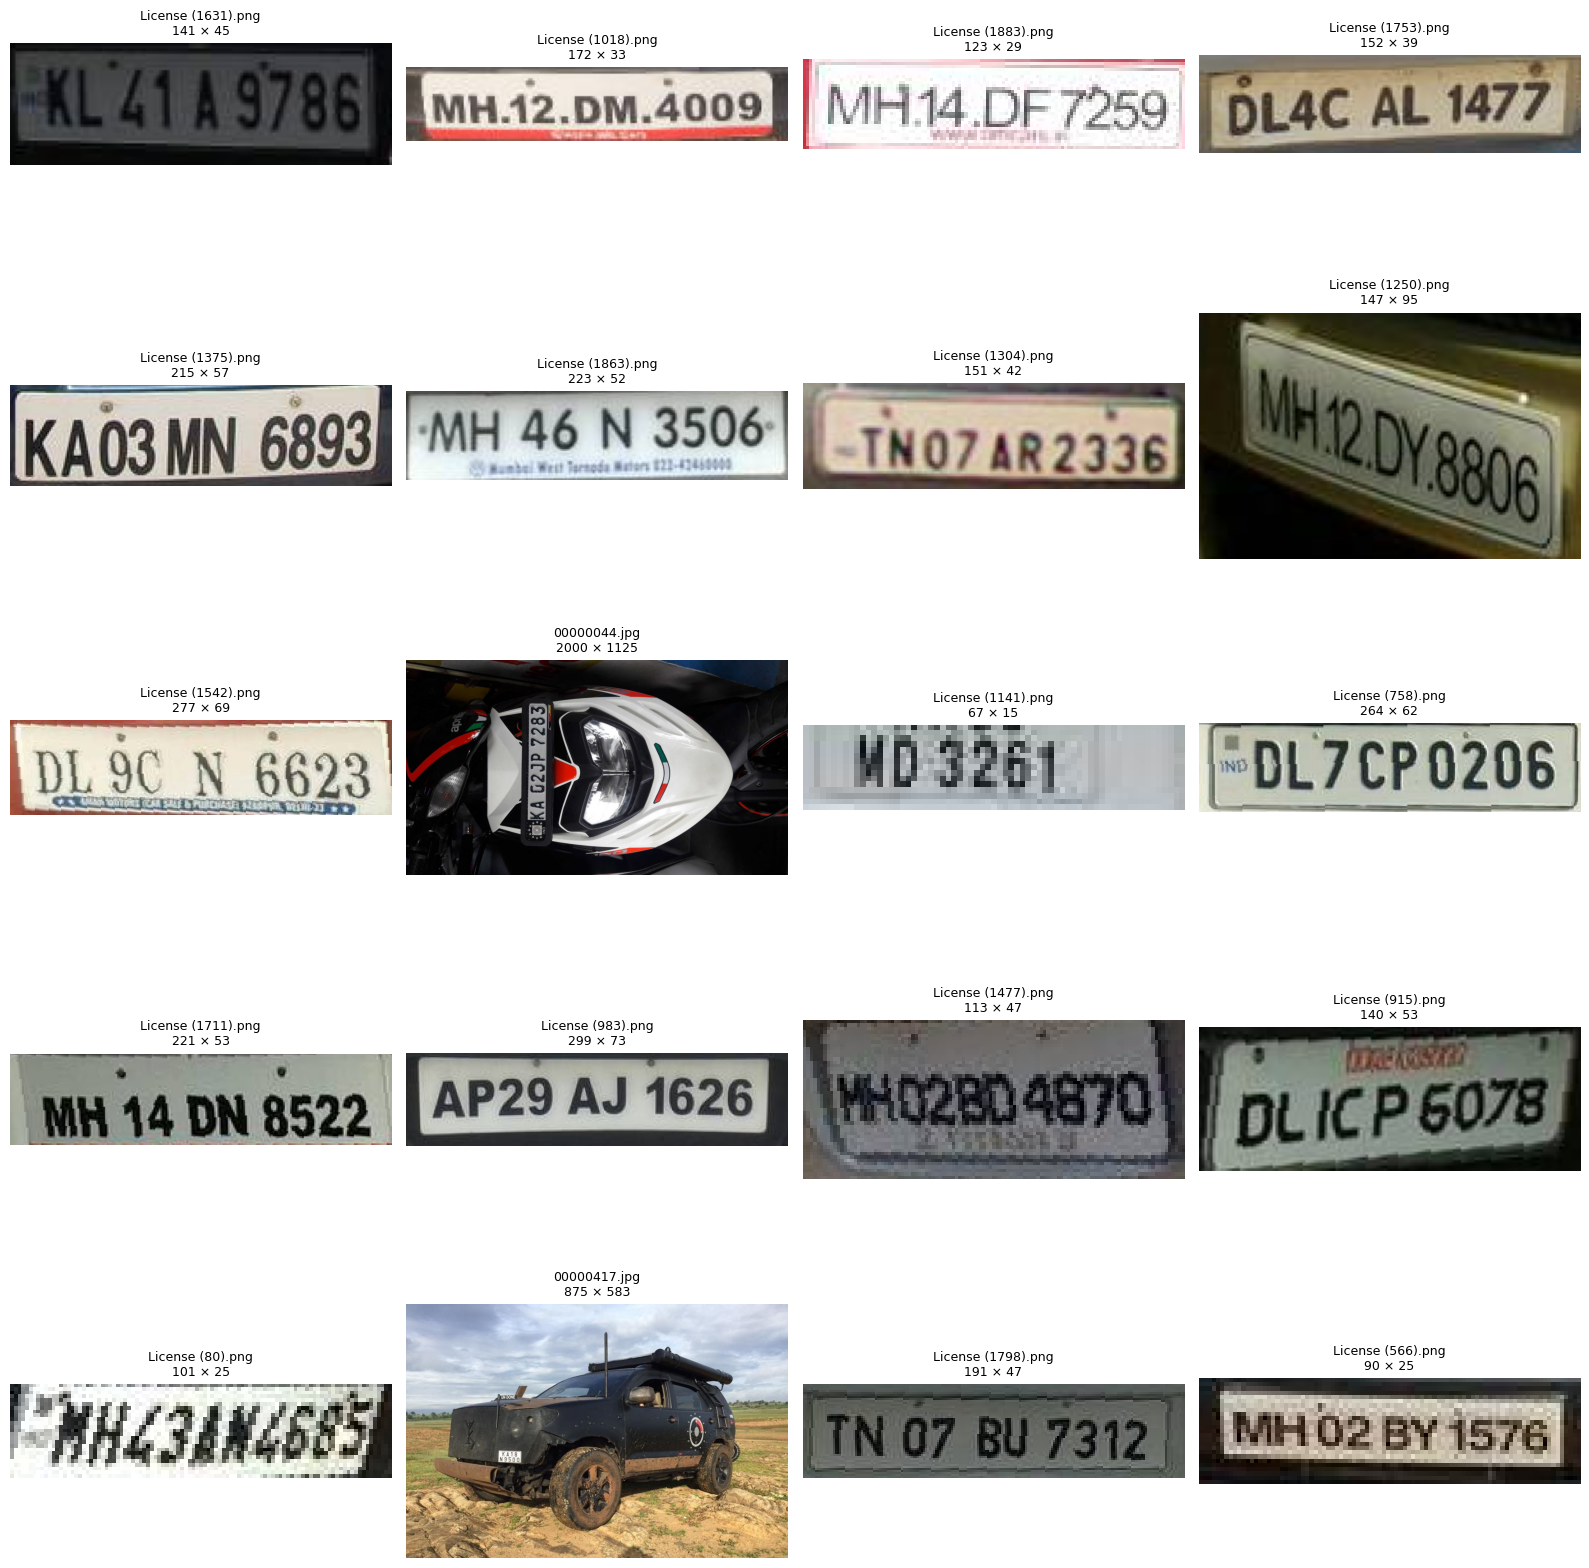

FINAL DATASET PREVIEW
Images available for LPSR: 1936


In [ ]:
# ============================================================
# CELL 17 — FINAL CLEAN DATASET PREVIEW
# ============================================================

import random
import math
import matplotlib.pyplot as plt
from PIL import Image

N = min(20, len(source_files))

samples = random.sample(source_files, N)

cols = 4
rows = math.ceil(N / cols)

plt.figure(figsize=(16, rows * 3.5))

for i, path in enumerate(samples):

    with Image.open(path) as img:

        img = img.convert("RGB")

        ax = plt.subplot(rows, cols, i + 1)

        ax.imshow(img)

        ax.set_title(
            f"{path.name}\n{img.size[0]} × {img.size[1]}",
            fontsize=9
        )

        ax.axis("off")

plt.tight_layout()
plt.show()

print("=" * 60)
print("FINAL DATASET PREVIEW")
print("=" * 60)
print("Images available for LPSR:", len(source_files))

In [ ]:
# ============================================================
# CELL 18 — TRAIN / VALIDATION SPLIT
# ============================================================

import random

SEED = 42
random.seed(SEED)

# source_files should already contain the 1,936 filtered images
if "source_files" not in globals() or len(source_files) == 0:
    raise RuntimeError(
        "source_files is empty. Run Cells 12–16 first."
    )

files = list(source_files)

random.shuffle(files)

VAL_FRACTION = 0.10

val_count = max(1, int(len(files) * VAL_FRACTION))

val_files = files[:val_count]
train_files = files[val_count:]

print("=" * 60)
print("LPSR TRAIN / VALIDATION SPLIT")
print("=" * 60)

print("Total images :", len(files))
print("Training     :", len(train_files))
print("Validation   :", len(val_files))
print("Validation % :", round(len(val_files) / len(files) * 100, 2))

print("=" * 60)

LPSR TRAIN / VALIDATION SPLIT
Total images : 1936
Training     : 1743
Validation   : 193
Validation % : 9.97


In [ ]:
# ============================================================
# CELL 19 — LPSR DATASET
# ============================================================

from torch.utils.data import Dataset, DataLoader
from PIL import Image, ImageOps
import torch
import numpy as np
import random

IMAGE_H = 64
IMAGE_W = 256

def load_rgb(path):
    with Image.open(path) as im:
        return im.convert("RGB").copy()


def pil_to_tensor(im):

    arr = np.asarray(im).astype(np.float32) / 255.0

    if arr.ndim == 2:
        arr = np.stack([arr] * 3, axis=-1)

    tensor = torch.from_numpy(arr)

    tensor = tensor.permute(2, 0, 1)

    return tensor.contiguous()


def prepare_plate(im):

    # Preserve the plate aspect ratio.
    im = ImageOps.contain(
        im,
        (IMAGE_W, IMAGE_H),
        method=Image.Resampling.LANCZOS
    )

    # Put the plate on a fixed-size canvas.
    canvas = Image.new(
        "RGB",
        (IMAGE_W, IMAGE_H),
        (0, 0, 0)
    )

    x = (IMAGE_W - im.width) // 2
    y = (IMAGE_H - im.height) // 2

    canvas.paste(im, (x, y))

    return canvas


def degrade_plate(clean):

    im = clean.copy()

    # --------------------------------------------------------
    # Random blur
    # --------------------------------------------------------

    if random.random() < 0.75:

        radius = random.uniform(
            0.2,
            1.4
        )

        im = im.filter(
            ImageFilter.GaussianBlur(radius)
        )

    # --------------------------------------------------------
    # Brightness
    # --------------------------------------------------------

    if random.random() < 0.60:

        factor = random.uniform(
            0.75,
            1.20
        )

        im = ImageEnhance.Brightness(
            im
        ).enhance(factor)

    # --------------------------------------------------------
    # Contrast
    # --------------------------------------------------------

    if random.random() < 0.60:

        factor = random.uniform(
            0.75,
            1.25
        )

        im = ImageEnhance.Contrast(
            im
        ).enhance(factor)

    # --------------------------------------------------------
    # Downsample → Upsample
    # --------------------------------------------------------

    if random.random() < 0.90:

        scale = random.uniform(
            0.35,
            0.75
        )

        small_w = max(
            16,
            int(IMAGE_W * scale)
        )

        small_h = max(
            8,
            int(IMAGE_H * scale)
        )

        im = im.resize(
            (small_w, small_h),
            Image.Resampling.BICUBIC
        )

        im = im.resize(
            (IMAGE_W, IMAGE_H),
            Image.Resampling.BICUBIC
        )

    # --------------------------------------------------------
    # Convert to tensor
    # --------------------------------------------------------

    x = pil_to_tensor(im)

    # --------------------------------------------------------
    # Sensor noise
    # --------------------------------------------------------

    if random.random() < 0.85:

        sigma = random.uniform(
            0.005,
            0.045
        )

        noise = torch.randn_like(x) * sigma

        x = x + noise

    # --------------------------------------------------------
    # Quantization
    # --------------------------------------------------------

    if random.random() < 0.55:

        levels = random.choice(
            [32, 48, 64, 96]
        )

        x = torch.round(
            x * levels
        ) / levels

    return x.clamp(0, 1)


class PlateLPSRDataset(Dataset):

    def __init__(
        self,
        files,
        train=True
    ):

        self.files = list(files)

        self.train = train

    def __len__(self):

        return len(self.files)

    def __getitem__(self, idx):

        path = self.files[idx]

        im = load_rgb(path)

        clean = prepare_plate(im)

        target = pil_to_tensor(clean)

        if self.train:

            degraded = degrade_plate(
                clean
            )

        else:

            # Deterministic validation degradation.
            state = random.getstate()

            random.seed(
                10000 + idx
            )

            degraded = degrade_plate(
                clean
            )

            random.setstate(state)

        return (
            degraded,
            target,
            str(path)
        )


train_dataset = PlateLPSRDataset(
    train_files,
    train=True
)

val_dataset = PlateLPSRDataset(
    val_files,
    train=False
)

print("=" * 60)
print("DATASET OBJECTS CREATED")
print("=" * 60)

print("Training samples   :", len(train_dataset))
print("Validation samples :", len(val_dataset))

DATASET OBJECTS CREATED
Training samples   : 1743
Validation samples : 193


In [ ]:
# ============================================================
# CELL 20 — DATALOADERS
# ============================================================

BATCH_SIZE = 16
NUM_WORKERS = 2

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

print("=" * 60)
print("DATALOADERS")
print("=" * 60)

print("Batch size       :", BATCH_SIZE)
print("Training batches :", len(train_loader))
print("Validation       :", len(val_loader))
print("=" * 60)

DATALOADERS
Batch size       : 16
Training batches : 109
Validation       : 13


In [ ]:
# ============================================================
# FIX — PIL IMPORTS
# ============================================================

from PIL import Image, ImageFilter, ImageEnhance, ImageOps

print("PIL image-processing modules loaded successfully.")

PIL image-processing modules loaded successfully.


File: /content/drive/MyDrive/car_detection/LPSR/data/downloaded_dataset/images/License (1520).png
Input shape : torch.Size([3, 64, 256])
Target shape: torch.Size([3, 64, 256])
Input range : 0.18246109783649445 to 0.8098542094230652
Target range: 0.0 to 1.0


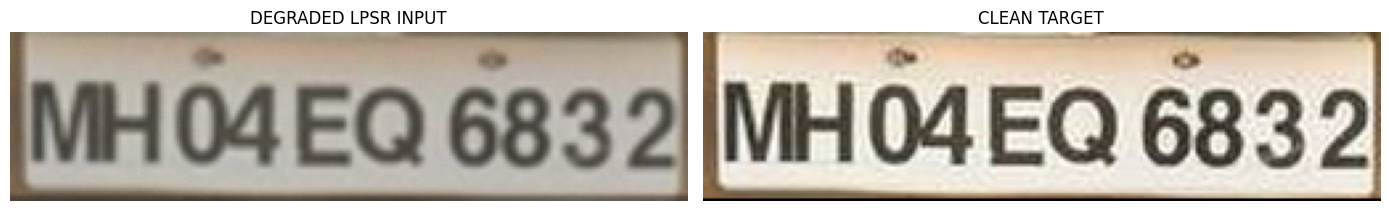

In [ ]:
# ============================================================
# CELL 21 — VERIFY LPSR INPUT / TARGET
# ============================================================

import matplotlib.pyplot as plt

lr, hr, path = train_dataset[0]

print("File:", path)
print("Input shape :", lr.shape)
print("Target shape:", hr.shape)

print(
    "Input range :",
    float(lr.min()),
    "to",
    float(lr.max())
)

print(
    "Target range:",
    float(hr.min()),
    "to",
    float(hr.max())
)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)

plt.imshow(
    lr.permute(1, 2, 0).numpy()
)

plt.title("DEGRADED LPSR INPUT")
plt.axis("off")


plt.subplot(1, 2, 2)

plt.imshow(
    hr.permute(1, 2, 0).numpy()
)

plt.title("CLEAN TARGET")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# CELL 22 — TRAFFIQ LPSR MODEL
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F


# ------------------------------------------------------------
# Residual Dense Block
# ------------------------------------------------------------

class RDB(nn.Module):

    def __init__(
        self,
        channels=64,
        growth=32,
        num_layers=4
    ):

        super().__init__()

        self.layers = nn.ModuleList()

        for i in range(num_layers):

            in_channels = channels + i * growth

            self.layers.append(
                nn.Conv2d(
                    in_channels,
                    growth,
                    kernel_size=3,
                    padding=1
                )
            )

        self.local_fusion = nn.Conv2d(
            channels + num_layers * growth,
            channels,
            kernel_size=1
        )

    def forward(self, x):

        features = [x]

        for layer in self.layers:

            inp = torch.cat(
                features,
                dim=1
            )

            out = F.relu(
                layer(inp),
                inplace=True
            )

            features.append(out)

        fused = self.local_fusion(
            torch.cat(features, dim=1)
        )

        return fused + x


# ------------------------------------------------------------
# Channel Attention
# ------------------------------------------------------------

class ChannelAttention(nn.Module):

    def __init__(
        self,
        channels,
        reduction=16
    ):

        super().__init__()

        hidden = max(
            channels // reduction,
            4
        )

        self.avg_pool = nn.AdaptiveAvgPool2d(1)

        self.fc = nn.Sequential(

            nn.Conv2d(
                channels,
                hidden,
                kernel_size=1
            ),

            nn.ReLU(inplace=True),

            nn.Conv2d(
                hidden,
                channels,
                kernel_size=1
            ),

            nn.Sigmoid()
        )

    def forward(self, x):

        attention = self.avg_pool(x)

        attention = self.fc(attention)

        return x * attention


# ------------------------------------------------------------
# Spatial Attention
# ------------------------------------------------------------

class SpatialAttention(nn.Module):

    def __init__(self):

        super().__init__()

        self.conv = nn.Conv2d(
            2,
            1,
            kernel_size=7,
            padding=3
        )

    def forward(self, x):

        avg = torch.mean(
            x,
            dim=1,
            keepdim=True
        )

        maximum = torch.max(
            x,
            dim=1,
            keepdim=True
        )[0]

        combined = torch.cat(
            [avg, maximum],
            dim=1
        )

        attention = torch.sigmoid(
            self.conv(combined)
        )

        return x * attention


# ------------------------------------------------------------
# CSAR Block
# ------------------------------------------------------------

class CSARBlock(nn.Module):

    def __init__(
        self,
        channels=64
    ):

        super().__init__()

        self.rdb = RDB(
            channels=channels
        )

        self.channel_attention = ChannelAttention(
            channels
        )

        self.spatial_attention = SpatialAttention()

    def forward(self, x):

        residual = x

        x = self.rdb(x)

        x = self.channel_attention(x)

        x = self.spatial_attention(x)

        return x + residual


# ------------------------------------------------------------
# TraffIQ LPSR
# ------------------------------------------------------------

class TraffiqLPSR(nn.Module):

    def __init__(
        self,
        in_channels=3,
        out_channels=3,
        features=64,
        num_blocks=4
    ):

        super().__init__()

        # Initial feature extraction
        self.head = nn.Conv2d(
            in_channels,
            features,
            kernel_size=3,
            padding=1
        )

        # CSAR feature blocks
        self.blocks = nn.ModuleList([

            CSARBlock(
                channels=features
            )

            for _ in range(num_blocks)

        ])

        # Global feature fusion
        self.global_fusion = nn.Conv2d(
            features * num_blocks,
            features,
            kernel_size=1
        )

        self.global_conv = nn.Conv2d(
            features,
            features,
            kernel_size=3,
            padding=1
        )

        # Reconstruction
        self.reconstruction = nn.Sequential(

            nn.Conv2d(
                features,
                features,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(inplace=True),

            nn.Conv2d(
                features,
                out_channels,
                kernel_size=3,
                padding=1
            )
        )

    def forward(self, x):

        # ----------------------------------------------------
        # Global residual reference
        # ----------------------------------------------------

        residual = x

        # ----------------------------------------------------
        # Initial features
        # ----------------------------------------------------

        x = self.head(x)

        block_outputs = []

        # ----------------------------------------------------
        # CSAR blocks
        # ----------------------------------------------------

        for block in self.blocks:

            x = block(x)

            block_outputs.append(x)

        # ----------------------------------------------------
        # Global feature fusion
        # ----------------------------------------------------

        fused = torch.cat(
            block_outputs,
            dim=1
        )

        fused = self.global_fusion(
            fused
        )

        fused = self.global_conv(
            fused
        )

        # ----------------------------------------------------
        # Reconstruction
        # ----------------------------------------------------

        output = self.reconstruction(
            fused
        )

        # ----------------------------------------------------
        # Global residual learning
        # ----------------------------------------------------

        output = output + residual

        return output.clamp(
            0,
            1
        )


print("=" * 60)
print("TraffIQ LPSR MODEL DEFINED")
print("=" * 60)

model = TraffiqLPSR()

print(model)

TraffIQ LPSR MODEL DEFINED
TraffiqLPSR(
  (head): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (blocks): ModuleList(
    (0-3): 4 x CSARBlock(
      (rdb): RDB(
        (layers): ModuleList(
          (0): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (1): Conv2d(96, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (3): Conv2d(160, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        )
        (local_fusion): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1))
      )
      (channel_attention): ChannelAttention(
        (avg_pool): AdaptiveAvgPool2d(output_size=1)
        (fc): Sequential(
          (0): Conv2d(64, 4, kernel_size=(1, 1), stride=(1, 1))
          (1): ReLU(inplace=True)
          (2): Conv2d(4, 64, kernel_size=(1, 1), stride=(1, 1))
          (3): Sigmoid()
        )
      )
      (spatial_attention): SpatialAtten

In [ ]:
# ============================================================
# CELL 23 — DEVICE SETUP
# ============================================================

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

model = model.to(DEVICE)

print("=" * 60)
print("DEVICE")
print("=" * 60)

print("Device:", DEVICE)

if DEVICE.type == "cuda":

    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

print("=" * 60)

DEVICE
Device: cuda
GPU: Tesla T4


In [ ]:
# ============================================================
# CELL 24 — LPSR FORWARD PASS TEST
# ============================================================

model.eval()

lr, hr, path = train_dataset[0]

lr_batch = lr.unsqueeze(0).to(DEVICE)

with torch.no_grad():

    sr_batch = model(
        lr_batch
    )

print("=" * 60)
print("FORWARD PASS TEST")
print("=" * 60)

print("Input shape :", tuple(lr_batch.shape))
print("Output shape:", tuple(sr_batch.shape))

print(
    "Input range :",
    float(lr_batch.min()),
    "to",
    float(lr_batch.max())
)

print(
    "Output range:",
    float(sr_batch.min()),
    "to",
    float(sr_batch.max())
)

print("=" * 60)

FORWARD PASS TEST
Input shape : (1, 3, 64, 256)
Output shape: (1, 3, 64, 256)
Input range : 0.0416666679084301 to 1.0
Output range: 0.057718951255083084 to 0.9386047124862671


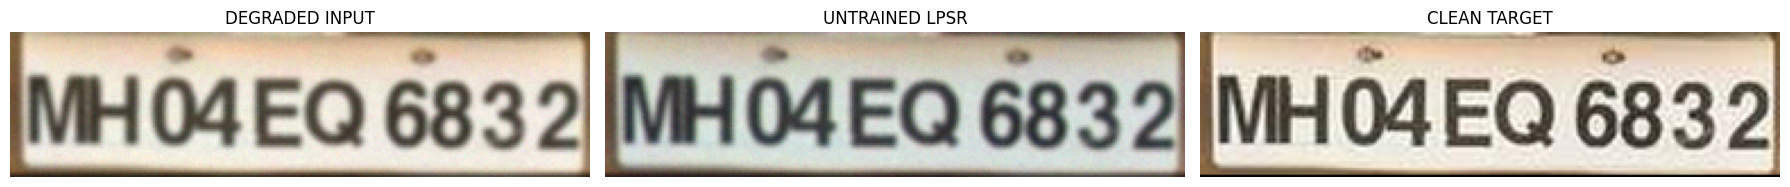

In [ ]:
# ============================================================
# CELL 25 — UNTRAINED MODEL VISUAL CHECK
# ============================================================

import matplotlib.pyplot as plt

model.eval()

with torch.no_grad():

    output = model(
        lr_batch
    )[0].cpu()

input_img = lr.cpu()
target_img = hr.cpu()
output_img = output


plt.figure(figsize=(18, 5))


plt.subplot(1, 3, 1)

plt.imshow(
    input_img.permute(1, 2, 0).numpy()
)

plt.title("DEGRADED INPUT")
plt.axis("off")


plt.subplot(1, 3, 2)

plt.imshow(
    output_img.permute(1, 2, 0).numpy()
)

plt.title("UNTRAINED LPSR")
plt.axis("off")


plt.subplot(1, 3, 3)

plt.imshow(
    target_img.permute(1, 2, 0).numpy()
)

plt.title("CLEAN TARGET")
plt.axis("off")


plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# CELL 26 — MODEL PARAMETERS
# ============================================================

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("=" * 60)
print("MODEL SIZE")
print("=" * 60)

print(
    "Total parameters     :",
    f"{total_params:,}"
)

print(
    "Trainable parameters :",
    f"{trainable_params:,}"
)

print(
    "Approx. FP32 memory  :",
    f"{total_params * 4 / (1024**2):.2f} MB"
)

print("=" * 60)

MODEL SIZE
Total parameters     : 662,559
Trainable parameters : 662,559
Approx. FP32 memory  : 2.53 MB


In [ ]:
# ============================================================
# CELL 27 — LPSR TRAINING CONFIGURATION
# ============================================================

import os
import time
import json
from pathlib import Path

# ------------------------------------------------------------
# Training parameters
# ------------------------------------------------------------

EPOCHS = 30

BATCH_SIZE = 16

LEARNING_RATE = 1e-4

WEIGHT_DECAY = 1e-6

NUM_WORKERS = 2

# ------------------------------------------------------------
# Device
# ------------------------------------------------------------

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# ------------------------------------------------------------
# Output directories
# ------------------------------------------------------------

LPSR_ROOT = (
    PROJECT_ROOT / "LPSR"
)

CHECKPOINT_DIR = (
    LPSR_ROOT / "checkpoints"
)

RESULTS_DIR = (
    LPSR_ROOT / "results"
)

LOG_DIR = (
    LPSR_ROOT / "logs"
)

CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

LOG_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# ------------------------------------------------------------
# Checkpoint files
# ------------------------------------------------------------

BEST_MODEL_PATH = (
    CHECKPOINT_DIR / "lpsr_best.pth"
)

LAST_MODEL_PATH = (
    CHECKPOINT_DIR / "lpsr_last.pth"
)

LOG_PATH = (
    LOG_DIR / "training_history.json"
)

# ------------------------------------------------------------
# Print configuration
# ------------------------------------------------------------

print("=" * 60)
print("TRAFFIQ LPSR TRAINING CONFIGURATION")
print("=" * 60)

print("Device        :", DEVICE)
print("Epochs        :", EPOCHS)
print("Batch size    :", BATCH_SIZE)
print("Learning rate :", LEARNING_RATE)
print("Weight decay  :", WEIGHT_DECAY)

print()
print("Training data :", len(train_dataset))
print("Validation    :", len(val_dataset))

print()
print("Best model:")
print(BEST_MODEL_PATH)

print()
print("Last model:")
print(LAST_MODEL_PATH)

print("=" * 60)

TRAFFIQ LPSR TRAINING CONFIGURATION
Device        : cuda
Epochs        : 30
Batch size    : 16
Learning rate : 0.0001
Weight decay  : 1e-06

Training data : 1743
Validation    : 193

Best model:
/content/drive/MyDrive/car_detection/LPSR/checkpoints/lpsr_best.pth

Last model:
/content/drive/MyDrive/car_detection/LPSR/checkpoints/lpsr_last.pth


In [ ]:
# ============================================================
# CELL 29 — LPSR LOSS FUNCTIONS
# ============================================================

import torch
import torch.nn.functional as F


# ------------------------------------------------------------
# L1 loss
# ------------------------------------------------------------

def l1_loss(pred, target):

    return F.l1_loss(
        pred,
        target
    )


# ------------------------------------------------------------
# Gradient loss
# ------------------------------------------------------------

def gradient_loss(pred, target):

    pred_x = pred[:, :, :, 1:] - pred[:, :, :, :-1]
    pred_y = pred[:, :, 1:, :] - pred[:, :, :-1, :]

    target_x = target[:, :, :, 1:] - target[:, :, :, :-1]
    target_y = target[:, :, 1:, :] - target[:, :, :-1, :]

    loss_x = F.l1_loss(
        pred_x,
        target_x
    )

    loss_y = F.l1_loss(
        pred_y,
        target_y
    )

    return loss_x + loss_y


# ------------------------------------------------------------
# Simple SSIM-style loss
# ------------------------------------------------------------

def structural_loss(pred, target):

    mu_x = F.avg_pool2d(
        pred,
        kernel_size=7,
        stride=1,
        padding=3
    )

    mu_y = F.avg_pool2d(
        target,
        kernel_size=7,
        stride=1,
        padding=3
    )

    sigma_x = F.avg_pool2d(
        pred * pred,
        kernel_size=7,
        stride=1,
        padding=3
    ) - mu_x * mu_x

    sigma_y = F.avg_pool2d(
        target * target,
        kernel_size=7,
        stride=1,
        padding=3
    ) - mu_y * mu_y

    sigma_xy = F.avg_pool2d(
        pred * target,
        kernel_size=7,
        stride=1,
        padding=3
    ) - mu_x * mu_y

    C1 = 0.01 ** 2
    C2 = 0.03 ** 2

    ssim_map = (
        (2 * mu_x * mu_y + C1)
        *
        (2 * sigma_xy + C2)
    ) / (
        (mu_x * mu_x + mu_y * mu_y + C1)
        *
        (sigma_x + sigma_y + C2)
        + 1e-8
    )

    return 1.0 - ssim_map.mean()


# ------------------------------------------------------------
# Combined loss
# ------------------------------------------------------------

def lpsr_loss(pred, target):

    loss_l1 = l1_loss(
        pred,
        target
    )

    loss_gradient = gradient_loss(
        pred,
        target
    )

    loss_structural = structural_loss(
        pred,
        target
    )

    total = (
        1.0 * loss_l1
        +
        0.10 * loss_gradient
        +
        0.10 * loss_structural
    )

    return (
        total,
        loss_l1,
        loss_gradient,
        loss_structural
    )


print("LPSR loss functions ready.")

LPSR loss functions ready.


In [ ]:
# ============================================================
# CELL 30 — OPTIMIZER
# ============================================================

model = model.to(DEVICE)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=4,
    min_lr=1e-7
)

print("=" * 60)
print("OPTIMIZER READY")
print("=" * 60)

print("Optimizer       : AdamW")
print("Initial LR      :", LEARNING_RATE)
print("Scheduler       : ReduceLROnPlateau")
print("=" * 60)

OPTIMIZER READY
Optimizer       : AdamW
Initial LR      : 0.0001
Scheduler       : ReduceLROnPlateau


In [ ]:
# ============================================================
# CELL 31 — PSNR
# ============================================================

import math

def calculate_psnr(pred, target):

    mse = F.mse_loss(
        pred,
        target
    ).item()

    if mse <= 1e-10:
        return 100.0

    return 10.0 * math.log10(
        1.0 / mse
    )


print("PSNR function ready.")

PSNR function ready.


In [ ]:
# ============================================================
# CELL 32 — TRAIN LPSR
# ============================================================

from tqdm.auto import tqdm

# ------------------------------------------------------------
# Make sure model is on correct device
# ------------------------------------------------------------

model = model.to(DEVICE)

# ------------------------------------------------------------
# Training history
# ------------------------------------------------------------

history = {
    "epoch": [],
    "train_loss": [],
    "val_loss": [],
    "train_l1": [],
    "val_l1": [],
    "train_psnr": [],
    "val_psnr": [],
    "learning_rate": []
}

best_val_loss = float("inf")

print("=" * 60)
print("STARTING LPSR TRAINING")
print("=" * 60)

print(
    f"Training samples   : {len(train_dataset)}"
)

print(
    f"Validation samples : {len(val_dataset)}"
)

print(
    f"Epochs             : {EPOCHS}"
)

print(
    f"Device             : {DEVICE}"
)

print("=" * 60)


# ============================================================
# EPOCH LOOP
# ============================================================

for epoch in range(1, EPOCHS + 1):

    epoch_start = time.time()

    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------

    model.train()

    train_total = 0.0
    train_l1_total = 0.0
    train_psnr_total = 0.0

    train_count = 0

    progress = tqdm(
        train_loader,
        desc=f"Epoch {epoch:02d}/{EPOCHS}",
        leave=True
    )

    for degraded, target, paths in progress:

        degraded = degraded.to(
            DEVICE,
            non_blocking=True
        )

        target = target.to(
            DEVICE,
            non_blocking=True
        )

        # ----------------------------------------------------
        # Clear gradients
        # ----------------------------------------------------

        optimizer.zero_grad(
            set_to_none=True
        )

        # ----------------------------------------------------
        # Forward
        # ----------------------------------------------------

        output = model(
            degraded
        )

        # ----------------------------------------------------
        # Loss
        # ----------------------------------------------------

        total_loss, loss_l1, _, _ = lpsr_loss(
            output,
            target
        )

        # ----------------------------------------------------
        # Backpropagation
        # ----------------------------------------------------

        total_loss.backward()

        # ----------------------------------------------------
        # Gradient clipping
        # ----------------------------------------------------

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        # ----------------------------------------------------
        # Update
        # ----------------------------------------------------

        optimizer.step()

        # ----------------------------------------------------
        # Statistics
        # ----------------------------------------------------

        batch_size_actual = degraded.size(0)

        train_total += (
            total_loss.item()
            * batch_size_actual
        )

        train_l1_total += (
            loss_l1.item()
            * batch_size_actual
        )

        train_psnr_total += (
            calculate_psnr(
                output.detach(),
                target
            )
            * batch_size_actual
        )

        train_count += batch_size_actual

        progress.set_postfix({
            "loss": f"{total_loss.item():.5f}",
            "psnr": f"{calculate_psnr(output.detach(), target):.2f}"
        })


    train_loss = (
        train_total / train_count
    )

    train_l1 = (
        train_l1_total / train_count
    )

    train_psnr = (
        train_psnr_total / train_count
    )


    # --------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------

    model.eval()

    val_total = 0.0
    val_l1_total = 0.0
    val_psnr_total = 0.0

    val_count = 0

    with torch.no_grad():

        for degraded, target, paths in val_loader:

            degraded = degraded.to(
                DEVICE,
                non_blocking=True
            )

            target = target.to(
                DEVICE,
                non_blocking=True
            )

            output = model(
                degraded
            )

            total_loss, loss_l1, _, _ = lpsr_loss(
                output,
                target
            )

            batch_size_actual = degraded.size(0)

            val_total += (
                total_loss.item()
                * batch_size_actual
            )

            val_l1_total += (
                loss_l1.item()
                * batch_size_actual
            )

            val_psnr_total += (
                calculate_psnr(
                    output,
                    target
                )
                * batch_size_actual
            )

            val_count += batch_size_actual


    val_loss = (
        val_total / val_count
    )

    val_l1 = (
        val_l1_total / val_count
    )

    val_psnr = (
        val_psnr_total / val_count
    )


    # --------------------------------------------------------
    # Scheduler
    # --------------------------------------------------------

    scheduler.step(
        val_loss
    )

    current_lr = optimizer.param_groups[0]["lr"]


    # --------------------------------------------------------
    # History
    # --------------------------------------------------------

    history["epoch"].append(
        epoch
    )

    history["train_loss"].append(
        train_loss
    )

    history["val_loss"].append(
        val_loss
    )

    history["train_l1"].append(
        train_l1
    )

    history["val_l1"].append(
        val_l1
    )

    history["train_psnr"].append(
        train_psnr
    )

    history["val_psnr"].append(
        val_psnr
    )

    history["learning_rate"].append(
        current_lr
    )


    # --------------------------------------------------------
    # Save LAST checkpoint
    # --------------------------------------------------------

    checkpoint = {

        "epoch": epoch,

        "model_state_dict":
            model.state_dict(),

        "optimizer_state_dict":
            optimizer.state_dict(),

        "scheduler_state_dict":
            scheduler.state_dict(),

        "best_val_loss":
            best_val_loss,

        "history":
            history,

        "config": {
            "image_height": IMAGE_H,
            "image_width": IMAGE_W,
            "epochs": EPOCHS,
            "batch_size": BATCH_SIZE,
            "learning_rate": LEARNING_RATE
        }
    }

    torch.save(
        checkpoint,
        LAST_MODEL_PATH
    )


    # --------------------------------------------------------
    # Save BEST checkpoint
    # --------------------------------------------------------

    is_best = (
        val_loss < best_val_loss
    )

    if is_best:

        best_val_loss = val_loss

        checkpoint["best_val_loss"] = (
            best_val_loss
        )

        torch.save(
            checkpoint,
            BEST_MODEL_PATH
        )


    # --------------------------------------------------------
    # Save history
    # --------------------------------------------------------

    with open(
        LOG_PATH,
        "w"
    ) as f:

        json.dump(
            history,
            f,
            indent=2
        )


    epoch_time = (
        time.time()
        - epoch_start
    )


    # --------------------------------------------------------
    # Print summary
    # --------------------------------------------------------

    print()
    print("=" * 60)

    print(
        f"Epoch {epoch:02d}/{EPOCHS}"
    )

    print(
        f"Train Loss : {train_loss:.6f}"
    )

    print(
        f"Val Loss   : {val_loss:.6f}"
    )

    print(
        f"Train PSNR : {train_psnr:.2f} dB"
    )

    print(
        f"Val PSNR   : {val_psnr:.2f} dB"
    )

    print(
        f"Learning Rate : {current_lr:.2e}"
    )

    print(
        f"Time       : {epoch_time:.1f} sec"
    )

    if is_best:
        print("★ NEW BEST MODEL SAVED")

    print("=" * 60)


print()
print("=" * 60)
print("TRAINING COMPLETE")
print("=" * 60)

print(
    "Best model:",
    BEST_MODEL_PATH
)

print(
    "Last model:",
    LAST_MODEL_PATH
)

print("=" * 60)

STARTING LPSR TRAINING
Training samples   : 1743
Validation samples : 193
Epochs             : 30
Device             : cuda


Epoch 01/30:   0%|          | 0/109 [00:00<?, ?it/s]


Epoch 01/30
Train Loss : 0.084353
Val Loss   : 0.083739
Train PSNR : 21.77 dB
Val PSNR   : 21.72 dB
Learning Rate : 1.00e-04
Time       : 51.8 sec
★ NEW BEST MODEL SAVED


Epoch 02/30:   0%|          | 0/109 [00:00<?, ?it/s]


Epoch 02/30
Train Loss : 0.080781
Val Loss   : 0.079915
Train PSNR : 21.94 dB
Val PSNR   : 21.98 dB
Learning Rate : 1.00e-04
Time       : 52.4 sec
★ NEW BEST MODEL SAVED


...

Epoch 29/30:   0%|          | 0/109 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d4a0eafe0c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d4a0eafe0c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/


Epoch 29/30
Train Loss : 0.061221
Val Loss   : 0.062150
Train PSNR : 23.32 dB
Val PSNR   : 23.19 dB
Learning Rate : 1.00e-04
Time       : 73.4 sec


Epoch 30/30:   0%|          | 0/109 [00:00<?, ?it/s]


Epoch 30/30
Train Loss : 0.059791
Val Loss   : 0.062148
Train PSNR : 23.49 dB
Val PSNR   : 23.24 dB
Learning Rate : 1.00e-04
Time       : 52.4 sec

TRAINING COMPLETE
Best model: /content/drive/MyDrive/car_detection/LPSR/checkpoints/lpsr_best.pth
Last model: /content/drive/MyDrive/car_detection/LPSR/checkpoints/lpsr_last.pth


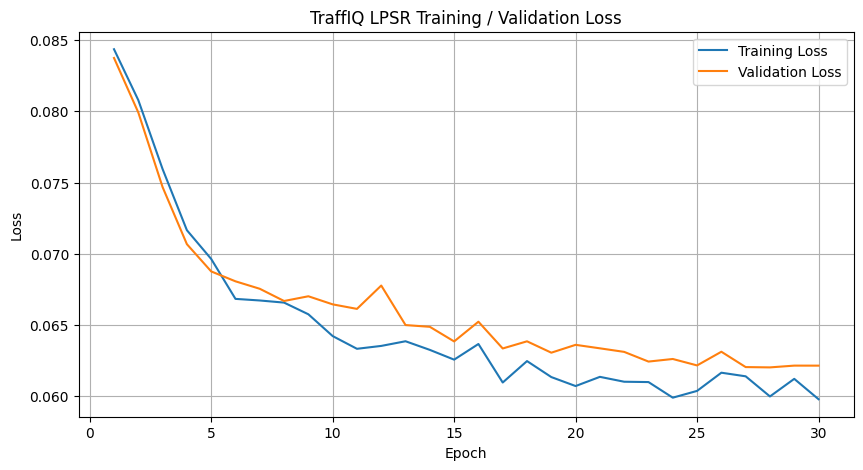

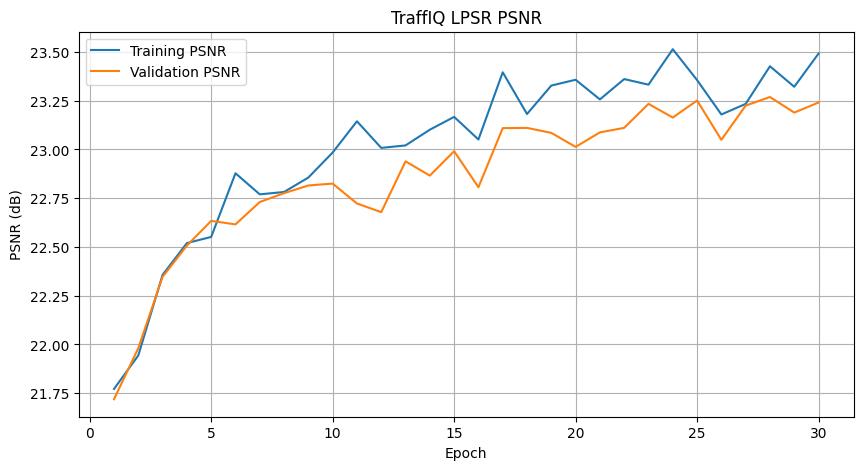

In [ ]:
# ============================================================
# CELL 33 — TRAINING CURVES
# ============================================================

import matplotlib.pyplot as plt

epochs = history["epoch"]

plt.figure(figsize=(10, 5))

plt.plot(
    epochs,
    history["train_loss"],
    label="Training Loss"
)

plt.plot(
    epochs,
    history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("TraffIQ LPSR Training / Validation Loss")
plt.legend()
plt.grid(True)

plt.show()


plt.figure(figsize=(10, 5))

plt.plot(
    epochs,
    history["train_psnr"],
    label="Training PSNR"
)

plt.plot(
    epochs,
    history["val_psnr"],
    label="Validation PSNR"
)

plt.xlabel("Epoch")
plt.ylabel("PSNR (dB)")
plt.title("TraffIQ LPSR PSNR")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# ============================================================
# CELL 34 — VERIFY BEST CHECKPOINT
# ============================================================

from pathlib import Path

print("=" * 60)
print("CHECKPOINT VERIFICATION")
print("=" * 60)

if BEST_MODEL_PATH.exists():

    size_mb = (
        BEST_MODEL_PATH.stat().st_size
        / (1024 * 1024)
    )

    print("✓ Best model exists")

    print(
        "Path:",
        BEST_MODEL_PATH
    )

    print(
        f"Size: {size_mb:.2f} MB"
    )

else:

    raise FileNotFoundError(
        f"Best checkpoint not found:\n{BEST_MODEL_PATH}"
    )


if LAST_MODEL_PATH.exists():

    size_mb = (
        LAST_MODEL_PATH.stat().st_size
        / (1024 * 1024)
    )

    print()
    print("✓ Last model exists")

    print(
        "Path:",
        LAST_MODEL_PATH
    )

    print(
        f"Size: {size_mb:.2f} MB"
    )

print("=" * 60)

CHECKPOINT VERIFICATION
✓ Best model exists
Path: /content/drive/MyDrive/car_detection/LPSR/checkpoints/lpsr_best.pth
Size: 7.67 MB

✓ Last model exists
Path: /content/drive/MyDrive/car_detection/LPSR/checkpoints/lpsr_last.pth
Size: 7.67 MB


In [ ]:
# ============================================================
# CELL 35 — LOAD BEST LPSR MODEL
# ============================================================

best_checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=DEVICE
)

model.load_state_dict(
    best_checkpoint["model_state_dict"]
)

model = model.to(DEVICE)

model.eval()

print("=" * 60)
print("BEST LPSR MODEL LOADED")
print("=" * 60)

print(
    "Best validation loss:",
    best_checkpoint["best_val_loss"]
)

print(
    "Checkpoint epoch:",
    best_checkpoint["epoch"]
)

print("=" * 60)

BEST LPSR MODEL LOADED
Best validation loss: 0.06202490585301206
Checkpoint epoch: 28


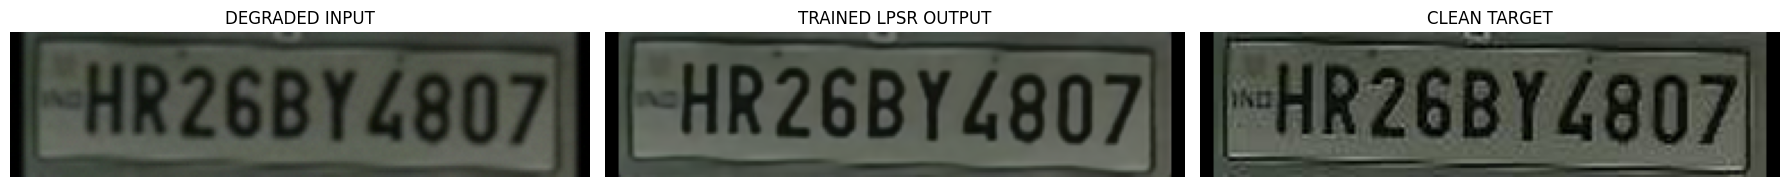

Plate: /content/drive/MyDrive/car_detection/LPSR/data/downloaded_dataset/images/License (800).png


In [ ]:
# ============================================================
# CELL 36 — BEST LPSR VISUAL RESULT
# ============================================================

model.eval()

# Take a validation sample
lr, hr, path = val_dataset[0]

input_tensor = (
    lr.unsqueeze(0)
    .to(DEVICE)
)

with torch.no_grad():

    sr = model(
        input_tensor
    )[0].cpu().clamp(0, 1)


lr_img = lr.cpu()
hr_img = hr.cpu()
sr_img = sr


plt.figure(figsize=(18, 5))


plt.subplot(1, 3, 1)

plt.imshow(
    lr_img.permute(1, 2, 0).numpy()
)

plt.title("DEGRADED INPUT")
plt.axis("off")


plt.subplot(1, 3, 2)

plt.imshow(
    sr_img.permute(1, 2, 0).numpy()
)

plt.title("TRAINED LPSR OUTPUT")
plt.axis("off")


plt.subplot(1, 3, 3)

plt.imshow(
    hr_img.permute(1, 2, 0).numpy()
)

plt.title("CLEAN TARGET")
plt.axis("off")


plt.tight_layout()
plt.show()

print("Plate:", path)